In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg
import matplotlib.colors as mcolors
from itertools import product
import random
import math
import pandas as pd
import sys
from collections import defaultdict
sys.path.insert(1, '../')
from Harmonic_degree import *
from HOLR_functions import *

In [18]:
# define functions

def harm_deg(Ag,clusters):
    G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf= H_CF_cluster(Ag,clusters)
    return deg_h

def harm_deg_m(Ag,clusters):
    G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf= H_CF_cluster(Ag,clusters)
    return M_deg_h
    
def harm_std(Ag,clusters):
    G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf= H_CF_cluster(Ag,clusters)
    val = (- std_h)
    return val

# This was modified version using variance instead of std, but it does not work properly
#def harm_var(Ag,clusters):
   # G, deg_h, M_deg_h, var_h, av_h, var_v_h, Not_h, deg_cf, M_deg_cf, var_cf, av_cf, var_v_cf, Not_cf= H_CF_cluster_2(Ag,clusters)
    #val = (- var_h)
    #return val


def cf_deg(Ag,clusters):
    G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf= H_CF_cluster(Ag,clusters)
    return deg_cf

def cf_deg_m(Ag,clusters):
    G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf= H_CF_cluster(Ag,clusters)
    return M_deg_cf
    
def cf_std(Ag,clusters):
    G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf= H_CF_cluster(Ag,clusters)
    val = (- std_cf)
    return val

# Same as harm_var
#def cf_var(Ag,clusters):
    #G, deg_h, M_deg_h, var_h, av_h, var_v_h, Not_h, deg_cf, M_deg_cf, var_cf, av_cf, var_v_cf, Not_cf= H_CF_cluster_2(Ag,clusters)
    #val = (- var_cf)
    #return val

# Converting dictionary in list of sets
def convert_to_communities(clusters):
    communities = {}
    for node, group in clusters.items():
        if group not in communities:
            communities[group] = set()
        communities[group].add(node)
    return list(communities.values()) 


# Harmonic modularity, we combine harmonic std and modularity
def mod_std_harm(Ag, clusters, lambda_param):
    communities = convert_to_communities(clusters)
    modularity = nx.community.modularity(Ag,communities)
    std_h_minus = harm_std(Ag,clusters)
    val = modularity + lambda_param * std_h_minus
    return val


In [19]:
clusters = {0: 1, 1: 0, 2: 1, 3: 2, 4: 0, 5: 2}
convert_to_communities(clusters)

[{0, 2}, {1, 4}, {3, 5}]

In [20]:
# Optimization

def random_partition(Ag, k):
    # Generate random partition
    partition = {}
    for node in Ag.nodes():
        partition[node] = random.randint(0, k-1)  # Randomly assign each node to a group
    return partition

def balanced_random_partition(Ag, k):
    nodes = list(Ag.nodes())
    random.shuffle(nodes)  # Shuffle nodes to ensure randomness
    partition = {}

    for i, node in enumerate(nodes):
        partition[node] = i % k  # Assign nodes cyclically to k groups

    return partition


def greedy_optimization(f, Ag, k, max_iterations=100, lambda_param = None):
    best_partition = balanced_random_partition(Ag, k)
    best_value = f(Ag, best_partition, lambda_param) if lambda_param is not None else f(Ag, best_partition)
    iteration = 0

    while iteration < max_iterations:
        improvement = False
        best_candidate_partition = best_partition
        best_candidate_value = best_value

        # Explore all possible single-node moves and pick the best one
        for node in Ag.nodes():
            current_group = best_partition[node]
            for new_group in range(k):
                if new_group != current_group:
                    new_partition = best_partition.copy()
                    new_partition[node] = new_group
                    new_value = f(Ag, new_partition, lambda_param) if lambda_param is not None else f(Ag, new_partition)
                    
                    # Instead of taking the first improvement, store the best move
                    if new_value > best_candidate_value:
                        best_candidate_value = new_value
                        best_candidate_partition = new_partition
                        improvement = True 
        # If no improvement, stop
        if not improvement:
            break
        
        # Apply the best move found in this iteration
        best_partition = best_candidate_partition
        best_value = best_candidate_value

        iteration += 1

    return best_partition


# Barabasi-Albert

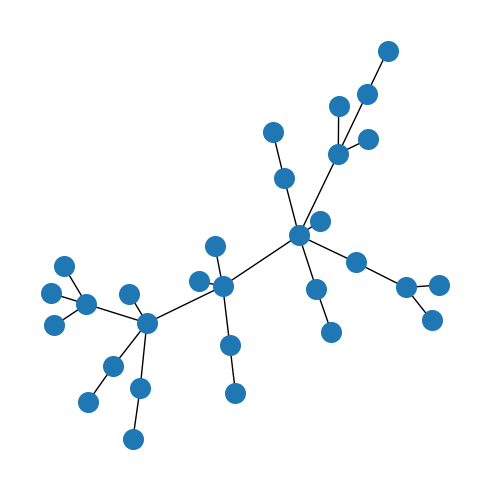

In [21]:
# Building a graph
Ag=nx.barabasi_albert_graph(30,1,seed=43)
pos=nx.spring_layout(Ag,iterations=250)
f,ax=plt.subplots(1,1,figsize=(5,5))
nx.draw(Ag,pos=pos,with_labels=False,node_size = 200)
plt.tight_layout()

# Only Harmonicity

In [53]:
clusters = greedy_optimization(harm_std, Ag, k = 4, max_iterations = 10000)

       H   Mod. H   Std. H       CF  Mod. CF  Std. CF
0.866667 0.906593 0.063807 0.066667 0.119048 0.896594


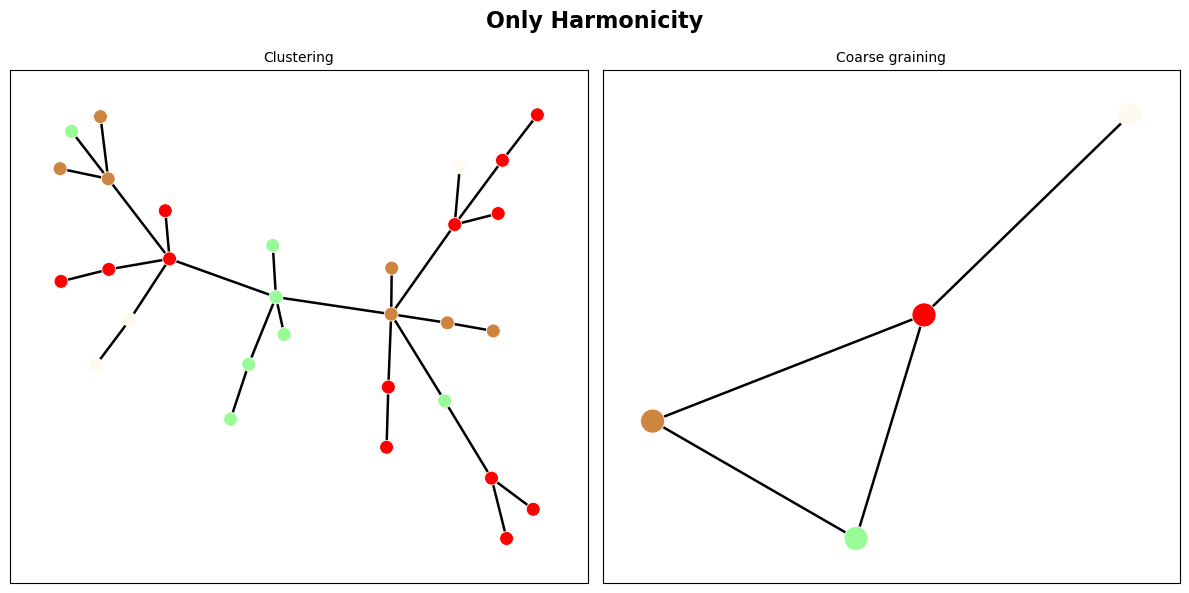

In [54]:
G, deg_h, M_deg_h, var_h, av_h, var_v_h, Not_h, deg_cf, M_deg_cf, var_cf, av_cf, var_v_cf, Not_cf= H_CF_cluster(Ag,clusters)
Values = [deg_h, M_deg_h, var_h, deg_cf, M_deg_cf, var_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
# Plotting
G, colors_d, sing_col = clust_plot(Ag,clusters)
# this should follow the natural order, so that the plot is correct
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
preimages = defaultdict(list)
for ag_node, g_node in clusters.items():
    preimages[g_node].append(ag_node)
# Step 2: Compute barycenters for G nodes
lay2=nx.spring_layout(G,iterations=70)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 100)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")
nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 300)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle("Only Harmonicity", fontsize=16, fontweight="bold")
plt.tight_layout()
print(df.to_string(index=False))

# Only Modularity

In [47]:
lambda_param = 0
clusters = greedy_optimization(mod_std_harm, Ag, k = 4, max_iterations = 10000, lambda_param = lambda_param)

       H   Mod. H  Std. H  CF  Mod. CF  Std. CF
0.866667 0.880952 0.06476 0.0      0.0 1.161023


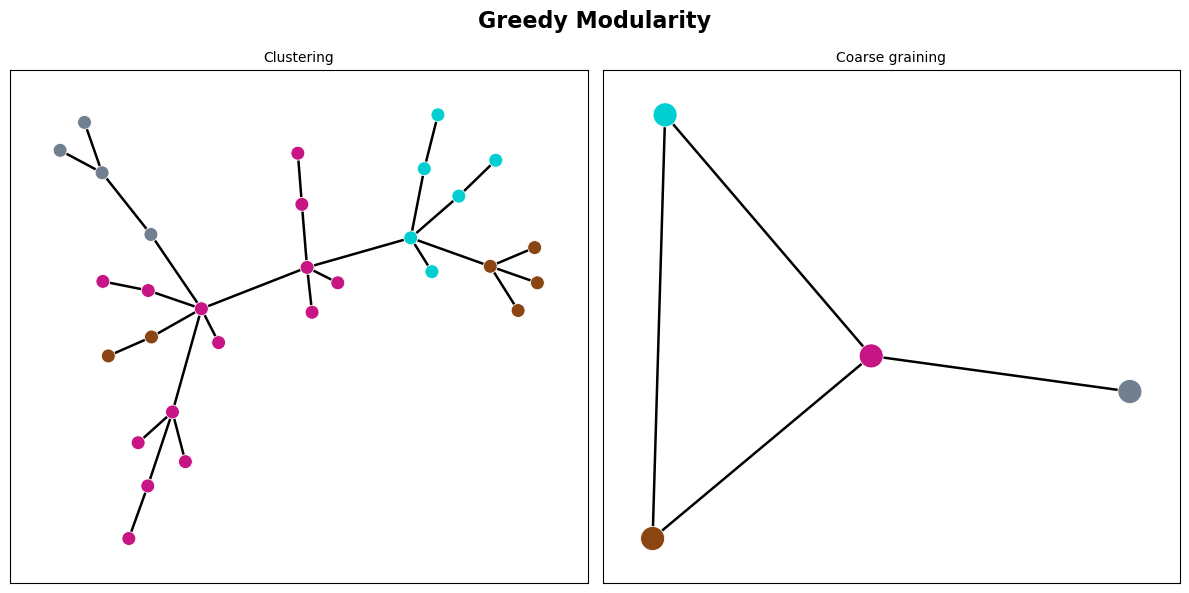

In [48]:
G, deg_h, M_deg_h, var_h, av_h, var_v_h, Not_h, deg_cf, M_deg_cf, var_cf, av_cf, var_v_cf, Not_cf= H_CF_cluster(Ag,clusters)
Values = [deg_h, M_deg_h, var_h, deg_cf, M_deg_cf, var_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
# Plotting
G, colors_d, sing_col = clust_plot(Ag,clusters)
# this should follow the natural order, so that the plot is correct
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
preimages = defaultdict(list)
for ag_node, g_node in clusters.items():
    preimages[g_node].append(ag_node)
# Step 2: Compute barycenters for G nodes
lay2=nx.spring_layout(G,iterations=70)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 100)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")
nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 300)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle("Greedy Modularity", fontsize=16, fontweight="bold")
plt.tight_layout()
print(df.to_string(index=False))

# Harmonic Modularity

In [28]:
lambda_param = 1
clusters = greedy_optimization(mod_std_harm, Ag, k = 4, max_iterations = 10000, lambda_param = lambda_param)

       H   Mod. H   Std. H  CF  Mod. CF  Std. CF
0.966667 0.958333 0.015713 0.0      0.0 1.006538


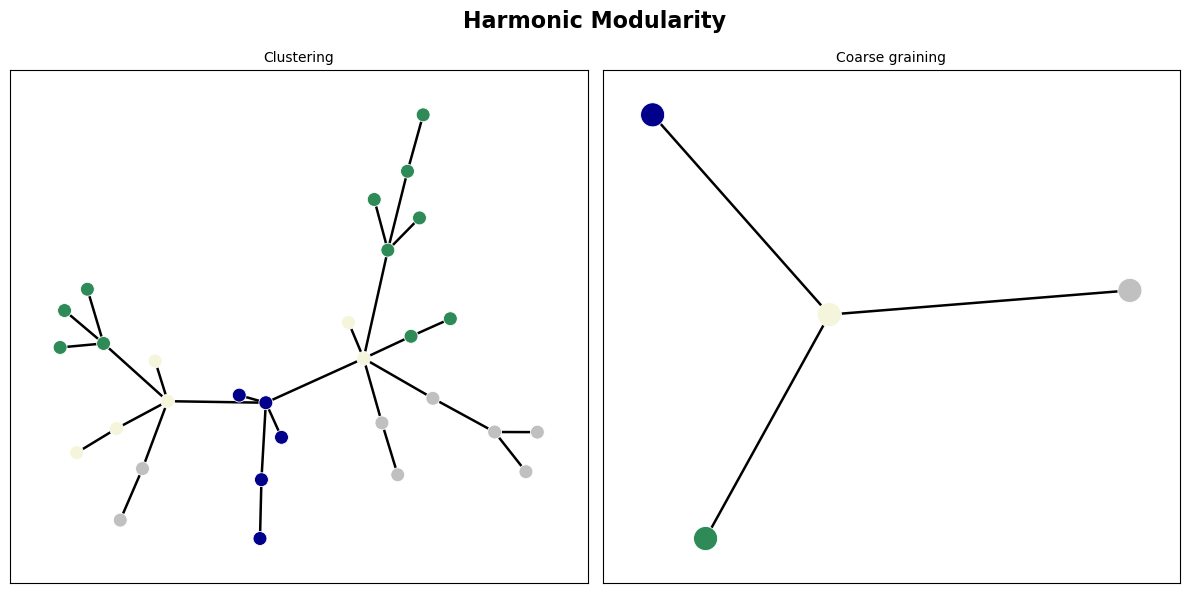

In [29]:
G, deg_h, M_deg_h, var_h, av_h, var_v_h, Not_h, deg_cf, M_deg_cf, var_cf, av_cf, var_v_cf, Not_cf= H_CF_cluster(Ag,clusters)
Values = [deg_h, M_deg_h, var_h, deg_cf, M_deg_cf, var_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
# Plotting
G, colors_d, sing_col = clust_plot(Ag,clusters)
# this should follow the natural order, so that the plot is correct
colors = [colors_d[n] for n in Ag.nodes()]
layout = nx.spring_layout(Ag, iterations=100)
preimages = defaultdict(list)
for ag_node, g_node in clusters.items():
    preimages[g_node].append(ag_node)
# Step 2: Compute barycenters for G nodes
lay2=nx.spring_layout(G,iterations=70)
f,ax = plt.subplots(1,2,figsize = (12,6))
ax = ax.flatten()
nodes = nx.draw_networkx_nodes(Ag,ax=ax[0],pos=layout,node_color=colors,node_size = 100)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[0],pos=layout, width = 1.8)
ax[0].collections[1].set_alpha(1)
ax[0].collections[0].set_linewidth(0.6) 
ax[0].collections[0].set_edgecolor("#FFFFFF") 
ax[0].set_title(f"Clustering")
nodes_2 = nx.draw_networkx_nodes(G,ax=ax[1],pos=lay2,node_color=sing_col,node_size = 300)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[1],pos=lay2, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Coarse graining")
f.suptitle("Harmonic Modularity", fontsize=16, fontweight="bold")
plt.tight_layout()
print(df.to_string(index=False))